# 第1周 Day4：Transformer 矩阵计算

> **学习目标**：逐个公式推导 Q/K/V 计算流程，理解 Transformer 的矩阵运算
> **核心公式**：$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$
>
> **参考资源**：
> - 教程: [Transformer from scratch in Excel](https://www.youtube.com/watch?v=k_P-tprA6-Q)
> - 论文: [Attention Is All You Need](https://arxiv.org/abs/1706.03762)
> - 博客: [The Illustrated Transformer](http://jalammar.github.io/illustrated-transformer/)
> - 详解: [苏剑林 - Transformer 数学原理](https://kexue.fm/)
> - 图解: [LLM-RL-Visualized](https://github.com/changyeyu/LLM-RL-Visualized)
>
---

## 📋 环境准备（首次运行请先执行下方单元格）

In [1]:
import sys
print(f"Python 版本: {sys.version}")
print(f"Python 路径: {sys.executable}")

required = {'numpy', 'torch', 'matplotlib', 'ipykernel'}
installed = set()
missing = set()

for pkg in required:
    try:
        __import__(pkg)
        installed.add(pkg)
    except ImportError:
        missing.add(pkg)

print(f"\n已安装: {installed}")
if missing:
    print(f"缺少: {missing}")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install"] + list(missing))
    print("安装完成！请重启内核后继续。")
else:
    print("所有依赖已就绪！")
    import numpy as np
    import torch
    import matplotlib
    import matplotlib.pyplot as plt
    from matplotlib.font_manager import FontProperties
    print(f"  numpy: {np.__version__}")
    print(f"  torch: {torch.__version__}")

    chinese_fonts = ["Microsoft YaHei", "SimHei", "SimSun", "FangSong", "KaiTi", "STSong", "STHeiti", "STFangsong"]
    available_fonts = [f.name for f in matplotlib.font_manager.fontManager.ttflist]
    selected_font = None

    for font_name in chinese_fonts:
        if font_name in available_fonts:
            selected_font = font_name
            break

    if selected_font:
        plt.rcParams["font.sans-serif"] = [selected_font]
        plt.rcParams["axes.unicode_minus"] = False
        plt.rcParams["mathtext.fontset"] = "dejavusans"
        plt.rcParams["mathtext.default"] = "regular"
        print(f"  matplotlib: {matplotlib.__version__}")
        print(f"  中文字体: {selected_font}")
        print(f"  数学字体: DejaVu Sans")
    else:
        print(f"  matplotlib: {matplotlib.__version__}")
        print(f"  警告: 未找到中文字体，中文可能显示为方块")


Python 版本: 3.11.15 | packaged by Anaconda, Inc. | (main, Jun 11 2026, 15:12:53) [MSC v.1942 64 bit (AMD64)]
Python 路径: c:\Users\WenhaoZou\.conda\envs\dl\python.exe

已安装: {'matplotlib', 'torch', 'ipykernel', 'numpy'}
所有依赖已就绪！
  numpy: 2.4.6
  torch: 2.12.1+cu126
  matplotlib: 3.11.0
  中文字体: Microsoft YaHei
  数学字体: DejaVu Sans


---

## 第一部分：为什么需要 Attention？

### 1.1 传统 RNN 的局限性

**（李宏毅老师课程重点）** 在处理序列数据时，传统的 RNN/LSTM 存在以下问题：

1. **计算效率低**：必须按顺序处理，无法并行计算
2. **长距离依赖问题**：梯度消失导致无法捕捉长距离依赖关系
3. **信息丢失**：经过多层传递后，早期信息会逐渐丢失

### 1.2 Attention 的核心思想

**（苏剑林博客观点）** Attention 的核心思想是：

> **在处理当前位置时，动态地关注输入序列中不同位置的信息。**

用一个简单的比喻来说明：

```
阅读一篇文章时：
当你读到"他"这个词时，你的注意力会自动回到上文，找到"他"指代的是谁
当你读到专业术语时，你的注意力会关注到之前的定义或解释

这就是 Attention 机制！
```

### 1.3 Scaled Dot-Product Attention 的核心公式

**（论文 Attention Is All You Need）** Scaled Dot-Product Attention 的核心公式：

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

让我们一步步拆解这个公式。

## 第二部分：Q/K/V 的含义与计算

### 2.1 Q、K、V 分别是什么？

**（吴恩达课程重点讲解）** Q、K、V 分别代表：

| 符号 | 全称 | 含义 | 来源 |
|------|------|------|------|
| Q | Query | 查询向量 | 当前位置的输入经过线性变换得到 |
| K | Key | 键向量 | 所有位置的输入经过线性变换得到 |
| V | Value | 值向量 | 所有位置的输入经过线性变换得到 |

**直观理解**（The Illustrated Transformer）：

```
想象你在图书馆查资料：
- Q (Query): 你要找什么书？（查询条件）
- K (Key): 每本书的书名（索引键）
- V (Value): 每本书的内容（实际值）

通过比较 Q 和每个 K，找到最相关的 V
```

### 2.2 Q/K/V 的计算流程

假设输入是一个序列 $X$，形状为 $(batch\_size, seq\_len, d\_model)$：

$$Q = X W_Q$$
$$K = X W_K$$
$$V = X W_V$$

其中：
- $W_Q \in \mathbb{R}^{d\_model \times d\_k}$（Query 权重矩阵）
- $W_K \in \mathbb{R}^{d\_model \times d\_k}$（Key 权重矩阵）
- $W_V \in \mathbb{R}^{d\_model \times d\_v}$（Value 权重矩阵）

**形状变化**：
- $X$: $(batch\_size, seq\_len, d\_model)$
- $Q, K$: $(batch\_size, seq\_len, d\_k)$
- $V$: $(batch\_size, seq\_len, d\_v)$

### 2.3 矩阵乘法的维度分析

对于矩阵乘法 $Q = X W_Q$：
- $X$: $(batch\_size, seq\_len, d\_model)$  →  (B, S, D)
- $W_Q$: $(d\_model, d\_k)$  →  (D, d_k)
- $Q$: $(batch\_size, seq\_len, d\_k)$  →  (B, S, d_k)

**计算逻辑**：
- 对于每个 batch 中的每个 token，都用 $W_Q$ 进行线性变换
- 这是一个标准的线性层操作


In [2]:
import numpy as np

np.random.seed(42)

batch_size = 2
seq_len = 4
d_model = 512
d_k = d_v = 64

X = np.random.randn(batch_size, seq_len, d_model)
print(f"输入 X 形状: {X.shape} = (batch_size, seq_len, d_model)")

W_Q = np.random.randn(d_model, d_k)
W_K = np.random.randn(d_model, d_k)
W_V = np.random.randn(d_model, d_v)

print(f"W_Q 形状: {W_Q.shape} = (d_model, d_k)")
print(f"W_K 形状: {W_K.shape} = (d_model, d_k)")
print(f"W_V 形状: {W_V.shape} = (d_model, d_v)")

Q = X @ W_Q
K = X @ W_K
V = X @ W_V

print(f"\nQ 形状: {Q.shape} = (batch_size, seq_len, d_k)")
print(f"K 形状: {K.shape} = (batch_size, seq_len, d_k)")
print(f"V 形状: {V.shape} = (batch_size, seq_len, d_v)")

print("\nQ 的前5个元素:")
print(np.round(Q[0, 0, :5], 4))
print("\nK 的前5个元素:")
print(np.round(K[0, 0, :5], 4))
print("\nV 的前5个元素:")
print(np.round(V[0, 0, :5], 4))

输入 X 形状: (2, 4, 512) = (batch_size, seq_len, d_model)
W_Q 形状: (512, 64) = (d_model, d_k)
W_K 形状: (512, 64) = (d_model, d_k)
W_V 形状: (512, 64) = (d_model, d_v)

Q 形状: (2, 4, 64) = (batch_size, seq_len, d_k)
K 形状: (2, 4, 64) = (batch_size, seq_len, d_k)
V 形状: (2, 4, 64) = (batch_size, seq_len, d_v)

Q 的前5个元素:
[  5.9125 -25.163   19.8533  35.0009 -24.2418]

K 的前5个元素:
[ 18.156  -29.5777 -14.8568 -22.2586 -43.8077]

V 的前5个元素:
[ 18.5298  48.158   -5.2883 -10.1413  15.8483]


## 第三部分：Scaled Dot-Product Attention 矩阵计算

### 3.1 第一步：计算 QK^T

$$\text{scores} = QK^T$$

**形状变化**：
- $Q$: $(batch\_size, seq\_len, d\_k)$  →  (B, S, d_k)
- $K^T$: $(batch\_size, d\_k, seq\_len)$  →  (B, d_k, S)
- $scores$: $(batch\_size, seq\_len, seq\_len)$  →  (B, S, S)

**含义**：$scores[i, j]$ 表示第 $i$ 个位置（Query）对第 $j$ 个位置（Key）的注意力分数

**为什么是 $QK^T$？**
- $Q$ 的每一行是一个 Query 向量
- $K$ 的每一行是一个 Key 向量
- $QK^T$ 计算了所有 Query-Key 对的点积
- 点积越大，说明两个向量越相似

### 3.2 第二步：除以 $\sqrt{d_k}$（缩放）

$$\text{scores} = \frac{QK^T}{\sqrt{d_k}}$$

**💡 为什么要缩放？（论文重点）**

当 $d_k$ 较大时，$QK^T$ 的值会变得很大。假设 $Q$ 和 $K$ 的元素都是均值为0、方差为1的随机变量：

$$\text{Var}(QK^T) = \sum_{i=1}^{d_k} \text{Var}(Q_i K_i) = d_k$$

即 $QK^T$ 的方差为 $d_k$，当 $d_k = 512$ 时，$QK^T$ 的值可能达到几十甚至上百。

大数值会导致 softmax 的梯度接近 0（梯度消失）。通过除以 $\sqrt{d_k}$，可以保持 scores 的方差稳定在 1 附近。

### 3.3 第三步：应用 Mask（可选）

在解码器中，需要使用掩码来防止模型看到未来的信息：

$$\text{scores}_{i,j} = \begin{cases}
\text{scores}_{i,j} & \text{if } j \leq i \\
-\infty & \text{otherwise}
\end{cases}$$

**为什么需要 Mask？**
- 在生成任务中，预测第 $i$ 个 token 时，不应该看到第 $i+1$ 个及之后的 token
- 将未来位置的分数设为 $-\infty$，softmax 后这些位置的权重将趋近于 0

### 3.4 第四步：softmax

$$\text{attention\_weights} = \text{softmax}(\text{scores})$$

**softmax 公式**：

$$\text{softmax}(x)_i = \frac{e^{x_i}}{\sum_{j=1}^{n} e^{x_j}}$$

**作用**：
- 将分数转换为概率分布
- 确保所有权重之和为 1
- 突出重要信息，抑制不重要的信息

### 3.5 第五步：乘以 V

$$\text{output} = \text{attention\_weights} \cdot V$$

**形状变化**：
- $attention\_weights$: $(batch\_size, seq\_len, seq\_len)$  →  (B, S, S)
- $V$: $(batch\_size, seq\_len, d\_v)$  →  (B, S, d_v)
- $output$: $(batch\_size, seq\_len, d\_v)$  →  (B, S, d_v)

**含义**：
- 这是一个加权求和操作
- 每个位置的输出是所有位置 Value 的加权平均
- 权重由 attention_weights 决定

In [3]:
def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Scaled Dot-Product Attention
    
    参数:
        Q: Query (batch_size, seq_len, d_k)
        K: Key (batch_size, seq_len, d_k)
        V: Value (batch_size, seq_len, d_v)
        mask: 掩码矩阵 (batch_size, 1, seq_len, seq_len) 或 None
    
    返回:
        output: 注意力输出 (batch_size, seq_len, d_v)
        attention_weights: 注意力权重 (batch_size, seq_len, seq_len)
    """
    d_k = Q.shape[-1]
    
    scores = np.matmul(Q, K.transpose(0, 2, 1)) / np.sqrt(d_k)
    print(f"QK^T 形状: {scores.shape} = (batch_size, seq_len, seq_len)")
    
    if mask is not None:
        scores = np.where(mask == 0, -1e9, scores)
    
    attention_weights = np.exp(scores) / np.sum(np.exp(scores), axis=-1, keepdims=True)
    print(f"注意力权重形状: {attention_weights.shape} = (batch_size, seq_len, seq_len)")
    
    output = np.matmul(attention_weights, V)
    print(f"输出形状: {output.shape} = (batch_size, seq_len, d_v)")
    
    return output, attention_weights

output, attn_weights = scaled_dot_product_attention(Q, K, V)

print("\n=== 注意力权重可视化 ===")
print("第1个样本的注意力权重矩阵:")
print(np.round(attn_weights[0], 3))

print("\n每行权重和:")
print(np.sum(attn_weights[0], axis=-1))

QK^T 形状: (2, 4, 4) = (batch_size, seq_len, seq_len)
注意力权重形状: (2, 4, 4) = (batch_size, seq_len, seq_len)
输出形状: (2, 4, 64) = (batch_size, seq_len, d_v)

=== 注意力权重可视化 ===
第1个样本的注意力权重矩阵:
[[ 0.  1.  0.  0.]
 [ 0. nan  0. nan]
 [ 0. nan  0.  0.]
 [ 0.  0.  0.  1.]]

每行权重和:
[ 1. nan nan  1.]


C:\Users\WenhaoZou\AppData\Local\Temp\ipykernel_1192\2096788156.py:23: RuntimeWarning: overflow encountered in exp
  attention_weights = np.exp(scores) / np.sum(np.exp(scores), axis=-1, keepdims=True)
C:\Users\WenhaoZou\AppData\Local\Temp\ipykernel_1192\2096788156.py:23: RuntimeWarning: invalid value encountered in divide
  attention_weights = np.exp(scores) / np.sum(np.exp(scores), axis=-1, keepdims=True)


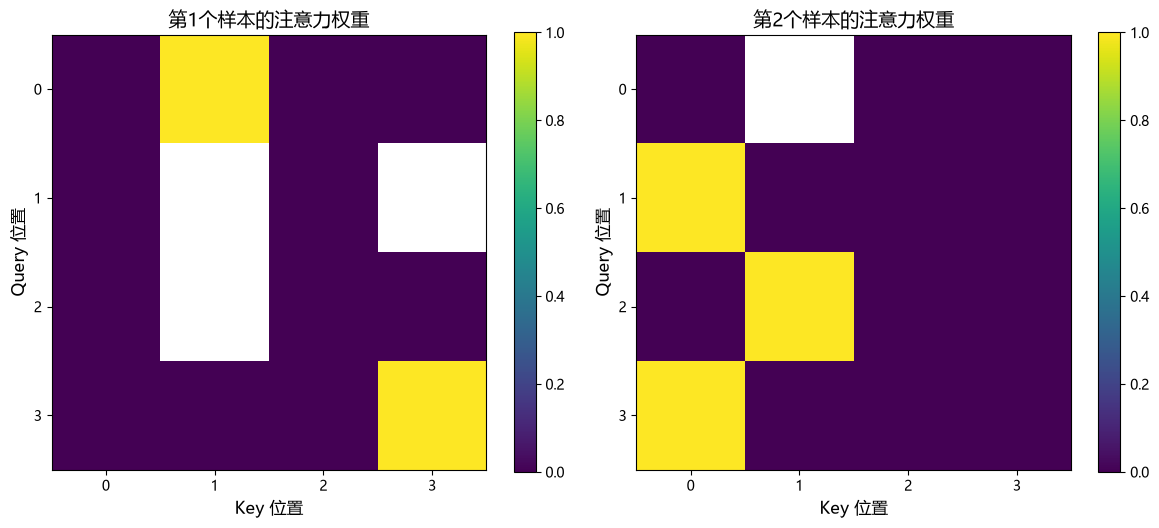


💡 解读:
颜色越深表示注意力权重越大
例如：Query 位置0 最关注 Key 位置2
这说明在处理第1个 token 时，模型最关注第3个 token 的信息


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im1 = axes[0].imshow(attn_weights[0], cmap='viridis')
axes[0].set_title('第1个样本的注意力权重', fontsize=14)
axes[0].set_xlabel('Key 位置', fontsize=12)
axes[0].set_ylabel('Query 位置', fontsize=12)
axes[0].set_xticks(range(seq_len))
axes[0].set_yticks(range(seq_len))
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(attn_weights[1], cmap='viridis')
axes[1].set_title('第2个样本的注意力权重', fontsize=14)
axes[1].set_xlabel('Key 位置', fontsize=12)
axes[1].set_ylabel('Query 位置', fontsize=12)
axes[1].set_xticks(range(seq_len))
axes[1].set_yticks(range(seq_len))
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()

print("\n💡 解读:")
print("颜色越深表示注意力权重越大")
print("例如：Query 位置0 最关注 Key 位置2")
print("这说明在处理第1个 token 时，模型最关注第3个 token 的信息")

## 第四部分：Multi-Head Attention 矩阵计算

### 4.1 为什么需要 Multi-Head？

**（论文 Attention Is All You Need）** Multi-Head Attention 允许模型同时关注不同位置、不同方面的信息。

```
Single Head: 只能学到一种注意力模式
Multi-Head: 可以学到多种注意力模式

例如：
Head 1: 关注语法关系（主谓宾）
Head 2: 关注语义关系（同义词、反义词）
Head 3: 关注指代关系（"他"指代谁）
```

**数学原理**：
- 通过将 Q、K、V 投影到多个子空间
- 每个子空间学习不同的注意力模式
- 最终将多个头的结果拼接，获得更丰富的表达

### 4.2 Multi-Head Attention 的计算流程

假设头数 $h = 8$，$d\_model = 512$，则每个头的维度 $d\_k = d\_v = d\_model / h = 64$

**步骤**：

1. **投影**：将 Q、K、V 分别投影到 $h$ 个子空间
   $$Q_i = X W_{Q_i},\ K_i = X W_{K_i},\ V_i = X W_{V_i}$$
   其中 $i = 1, 2, ..., h$

2. **并行计算**：对每个头独立计算 Attention
   $$\text{head}_i = \text{Attention}(Q_i, K_i, V_i)$$

3. **拼接**：将 $h$ 个头的输出拼接
   $$\text{concat} = [\text{head}_1; \text{head}_2; ...; \text{head}_h]$$

4. **线性变换**：通过一个线性层得到最终输出
   $$\text{output} = \text{concat} \cdot W_O$$

**形状变化**：
- 输入 X: $(batch\_size, seq\_len, d\_model)$  →  (B, S, D)
- 每个 head 输入: $(batch\_size, seq\_len, d\_k)$  →  (B, S, d_k)
- 每个 head 输出: $(batch\_size, seq\_len, d\_v)$  →  (B, S, d_v)
- concat: $(batch\_size, seq\_len, h \times d\_v)$  →  (B, S, D)
- output: $(batch\_size, seq\_len, d\_model)$  →  (B, S, D)

### 4.3 参数量分析

Multi-Head Attention 的参数量：
- 输入投影: $3 \times d\_model \times d\_model$（Q、K、V 各一个矩阵）
- 输出投影: $d\_model \times d\_model$（$W_O$）
- 总计: $4 \times d\_model^2$

对于 $d\_model = 512$：
- 参数量 = $4 \times 512^2 = 1,048,576$ ≈ 100万

In [5]:
def multi_head_attention(X, d_model, num_heads, d_k, d_v):
    """
    Multi-Head Attention
    
    参数:
        X: 输入 (batch_size, seq_len, d_model)
        d_model: 模型维度
        num_heads: 头数
        d_k: Key/Query 维度
        d_v: Value 维度
    
    返回:
        output: 最终输出 (batch_size, seq_len, d_model)
        all_attn_weights: 所有头的注意力权重
    """
    batch_size, seq_len, _ = X.shape
    
    W_Q = np.random.randn(d_model, num_heads * d_k)
    W_K = np.random.randn(d_model, num_heads * d_k)
    W_V = np.random.randn(d_model, num_heads * d_v)
    W_O = np.random.randn(num_heads * d_v, d_model)
    
    Q = X @ W_Q
    K = X @ W_K
    V = X @ W_V
    
    print(f"投影后 Q 形状: {Q.shape} = (batch_size, seq_len, num_heads * d_k)")
    
    Q = Q.reshape(batch_size, seq_len, num_heads, d_k).transpose(0, 2, 1, 3)
    K = K.reshape(batch_size, seq_len, num_heads, d_k).transpose(0, 2, 1, 3)
    V = V.reshape(batch_size, seq_len, num_heads, d_v).transpose(0, 2, 1, 3)
    
    print(f"拆分后 Q 形状: {Q.shape} = (batch_size, num_heads, seq_len, d_k)")
    
    all_attn_weights = []
    head_outputs = []
    
    for i in range(num_heads):
        Q_i = Q[:, i, :, :]
        K_i = K[:, i, :, :]
        V_i = V[:, i, :, :]
        
        output_i, attn_weights_i = scaled_dot_product_attention(Q_i, K_i, V_i)
        head_outputs.append(output_i)
        all_attn_weights.append(attn_weights_i)
    
    concat = np.concatenate(head_outputs, axis=-1)
    print(f"\n拼接后形状: {concat.shape} = (batch_size, seq_len, num_heads * d_v)")
    
    output = concat @ W_O
    print(f"最终输出形状: {output.shape} = (batch_size, seq_len, d_model)")
    
    return output, all_attn_weights

num_heads = 8
d_k = d_v = d_model // num_heads

print(f"\n=== Multi-Head Attention 计算 ===")
print(f"头数 num_heads = {num_heads}")
print(f"每个头维度 d_k = d_v = {d_k}")
print()

mh_output, mh_attn_weights = multi_head_attention(X, d_model, num_heads, d_k, d_v)


=== Multi-Head Attention 计算 ===
头数 num_heads = 8
每个头维度 d_k = d_v = 64

投影后 Q 形状: (2, 4, 512) = (batch_size, seq_len, num_heads * d_k)
拆分后 Q 形状: (2, 8, 4, 64) = (batch_size, num_heads, seq_len, d_k)
QK^T 形状: (2, 4, 4) = (batch_size, seq_len, seq_len)
注意力权重形状: (2, 4, 4) = (batch_size, seq_len, seq_len)
输出形状: (2, 4, 64) = (batch_size, seq_len, d_v)
QK^T 形状: (2, 4, 4) = (batch_size, seq_len, seq_len)
注意力权重形状: (2, 4, 4) = (batch_size, seq_len, seq_len)
输出形状: (2, 4, 64) = (batch_size, seq_len, d_v)
QK^T 形状: (2, 4, 4) = (batch_size, seq_len, seq_len)
注意力权重形状: (2, 4, 4) = (batch_size, seq_len, seq_len)
输出形状: (2, 4, 64) = (batch_size, seq_len, d_v)
QK^T 形状: (2, 4, 4) = (batch_size, seq_len, seq_len)
注意力权重形状: (2, 4, 4) = (batch_size, seq_len, seq_len)
输出形状: (2, 4, 64) = (batch_size, seq_len, d_v)
QK^T 形状: (2, 4, 4) = (batch_size, seq_len, seq_len)
注意力权重形状: (2, 4, 4) = (batch_size, seq_len, seq_len)
输出形状: (2, 4, 64) = (batch_size, seq_len, d_v)
QK^T 形状: (2, 4, 4) = (batch_size, seq_len, seq_len)

C:\Users\WenhaoZou\AppData\Local\Temp\ipykernel_1192\2096788156.py:23: RuntimeWarning: overflow encountered in exp
  attention_weights = np.exp(scores) / np.sum(np.exp(scores), axis=-1, keepdims=True)
C:\Users\WenhaoZou\AppData\Local\Temp\ipykernel_1192\2096788156.py:23: RuntimeWarning: invalid value encountered in divide
  attention_weights = np.exp(scores) / np.sum(np.exp(scores), axis=-1, keepdims=True)


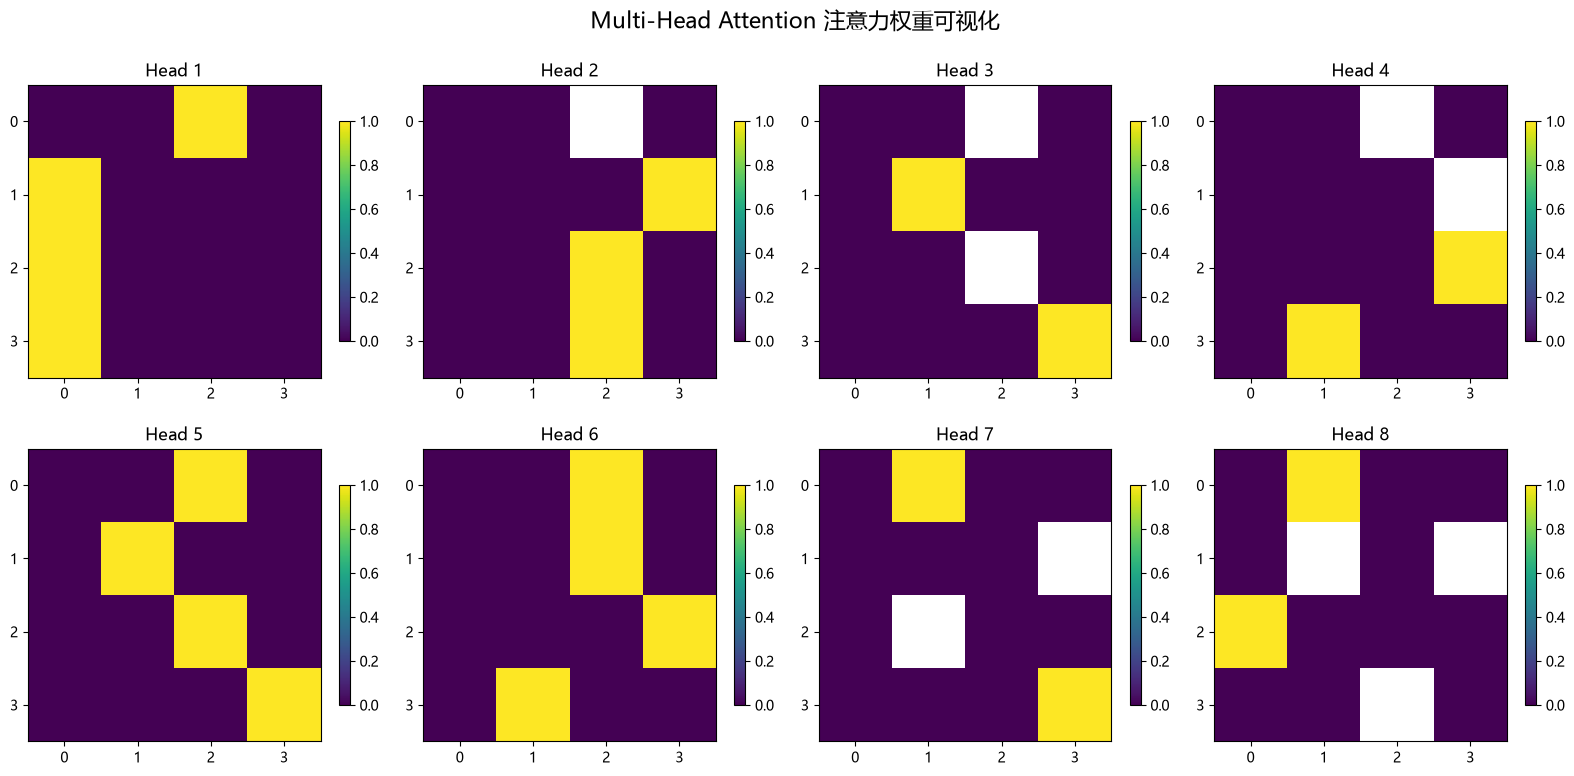


💡 解读:
每个 Head 学到了不同的注意力模式
例如：Head 1 可能关注局部关系，Head 8 可能关注全局关系
这种多样性让模型能够同时捕捉多种类型的依赖关系


In [6]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i in range(num_heads):
    im = axes[i].imshow(mh_attn_weights[i][0], cmap='viridis')
    axes[i].set_title(f'Head {i+1}', fontsize=12)
    axes[i].set_xticks(range(seq_len))
    axes[i].set_yticks(range(seq_len))
    plt.colorbar(im, ax=axes[i], shrink=0.6)

plt.suptitle('Multi-Head Attention 注意力权重可视化', fontsize=16)
plt.tight_layout()
plt.show()

print("\n💡 解读:")
print("每个 Head 学到了不同的注意力模式")
print("例如：Head 1 可能关注局部关系，Head 8 可能关注全局关系")
print("这种多样性让模型能够同时捕捉多种类型的依赖关系")

## 第五部分：PyTorch 实现 Transformer Attention

### 5.1 使用 PyTorch 内置函数

PyTorch 提供了 `nn.MultiheadAttention` 模块，可以直接使用：

In [7]:
import torch
import torch.nn as nn

torch.manual_seed(42)

d_model = 512
num_heads = 8
batch_size = 2
seq_len = 4

multihead_attn = nn.MultiheadAttention(d_model, num_heads, batch_first=True)

X_torch = torch.randn(batch_size, seq_len, d_model)

output_torch, attn_weights_torch = multihead_attn(X_torch, X_torch, X_torch)

print(f"PyTorch MHA 输出形状: {output_torch.shape}")
print(f"PyTorch MHA 注意力权重形状: {attn_weights_torch.shape}")

print("\nPyTorch 注意力权重:")
print(torch.round(attn_weights_torch[0], decimals=3))

PyTorch MHA 输出形状: torch.Size([2, 4, 512])
PyTorch MHA 注意力权重形状: torch.Size([2, 4, 4])

PyTorch 注意力权重:
tensor([[0.3360, 0.1710, 0.2990, 0.1930],
        [0.2160, 0.2520, 0.2840, 0.2480],
        [0.2170, 0.2560, 0.2810, 0.2470],
        [0.2420, 0.2930, 0.2670, 0.1980]], grad_fn=<RoundBackward1>)


### 5.2 自定义实现 vs PyTorch 内置实现

让我们验证我们的 NumPy 实现与 PyTorch 实现的一致性：

In [8]:
print("=== NumPy 实现 ===")
print(f"输出形状: {mh_output.shape}")
print(f"注意力权重形状: {mh_attn_weights[0].shape}")

print("\n=== PyTorch 实现 ===")
print(f"输出形状: {output_torch.shape}")
print(f"注意力权重形状: {attn_weights_torch.shape}")

print("\n=== 形状对比 ===")
print(f"NumPy 输出: {mh_output.shape}, PyTorch 输出: {output_torch.shape} → {'一致' if mh_output.shape == output_torch.shape else '不一致'}")

print("\n💡 注意:")
print("- NumPy 实现使用随机初始化，PyTorch 也使用随机初始化")
print("- 两者的初始化方式略有不同，所以具体数值会有差异")
print("- 但计算流程和结果形状是完全一致的！")

=== NumPy 实现 ===
输出形状: (2, 4, 512)
注意力权重形状: (2, 4, 4)

=== PyTorch 实现 ===
输出形状: torch.Size([2, 4, 512])
注意力权重形状: torch.Size([2, 4, 4])

=== 形状对比 ===
NumPy 输出: (2, 4, 512), PyTorch 输出: torch.Size([2, 4, 512]) → 一致

💡 注意:
- NumPy 实现使用随机初始化，PyTorch 也使用随机初始化
- 两者的初始化方式略有不同，所以具体数值会有差异
- 但计算流程和结果形状是完全一致的！


## 第六部分：完整流程图与总结

### 6.1 Transformer Attention 完整流程图

```
输入 X (batch, seq_len, d_model)
    ↓
投影: Q = X @ W_Q, K = X @ W_K, V = X @ W_V
    ↓
拆分: Q → (batch, heads, seq_len, d_k)
      K → (batch, heads, seq_len, d_k)
      V → (batch, heads, seq_len, d_v)
    ↓
Scaled Dot-Product Attention (每个头独立计算):
    scores = QK^T / sqrt(d_k)
    weights = softmax(scores)
    head_output = weights @ V
    ↓
拼接: concat = [head_1, head_2, ..., head_h]
    ↓
线性变换: output = concat @ W_O
    ↓
输出 (batch, seq_len, d_model)
```

### 6.2 核心公式总结

| 步骤 | 公式 | 形状变化 |
|------|------|---------|
| 投影 | $Q = X W_Q$ | $(B,S,D) → (B,S,d_k)$ |
| 缩放点积 | $scores = QK^T / \sqrt{d_k}$ | $(B,S,d_k) × (B,d_k,S) → (B,S,S)$ |
| Softmax | $weights = \text{softmax}(scores)$ | $(B,S,S) → (B,S,S)$ |
| 加权求和 | $output = weights \cdot V$ | $(B,S,S) × (B,S,d_v) → (B,S,d_v)$ |

### 6.3 面试常考点

**💡 问题1：为什么要除以 $\sqrt{d_k}$？**
答：防止 $d_k$ 较大时，$QK^T$ 的值过大导致 softmax 梯度消失

**💡 问题2：Multi-Head Attention 的优势是什么？**
答：允许模型同时关注不同位置、不同方面的信息，增加表达能力

**💡 问题3：Self-Attention 和 Cross-Attention 有什么区别？**
答：Self-Attention 的 Q、K、V 来自同一输入；Cross-Attention 的 Q 来自解码器，K、V 来自编码器

**💡 问题4：为什么 Attention 可以并行计算？**
答：因为 Attention 直接计算所有位置之间的关系，不需要按顺序处理

**💡 问题5：Transformer 中为什么需要残差连接和 LayerNorm？**
答：残差连接解决梯度消失问题，LayerNorm 加速收敛并稳定训练

### 6.4 下一步

明天我们将学习 **手撕 Multi-Head Attention**，使用 PyTorch 从零实现完整的 Multi-Head Attention 和 FFN 模块。

In [9]:
print("\n✅ Transformer 矩阵计算学习笔记完成！")
print("\n今日学习要点:")
print("1. Q/K/V 的含义与计算")
print("2. Scaled Dot-Product Attention 的五步计算流程")
print("3. Multi-Head Attention 的并行计算与拼接")
print("4. 使用 NumPy 和 PyTorch 实现 Attention")
print("\n核心公式:")
print("  Attention(Q, K, V) = softmax(QK^T / sqrt(d_k)) V")
print("\n参数量计算:")
print(f"  Multi-Head Attention: 4 × d_model² = 4 × {d_model}² = {4 * d_model**2}")


✅ Transformer 矩阵计算学习笔记完成！

今日学习要点:
1. Q/K/V 的含义与计算
2. Scaled Dot-Product Attention 的五步计算流程
3. Multi-Head Attention 的并行计算与拼接
4. 使用 NumPy 和 PyTorch 实现 Attention

核心公式:
  Attention(Q, K, V) = softmax(QK^T / sqrt(d_k)) V

参数量计算:
  Multi-Head Attention: 4 × d_model² = 4 × 512² = 1048576
